<a href="https://colab.research.google.com/github/sanketjagdale325-png/nlp-pipeline-Practical/blob/main/GenAI_Practical2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
!pip install gensim


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 27.9/27.9 MB 22.9 MB/s eta 0:00:00


In [ ]:
from gensim.models import Word2Vec

sentences = [

    ['the','king','rules','the','kingdom'],
    ['the', 'queen', 'rules', 'the', 'kingdom'],
    ['the', 'prince', 'rules', 'the', 'kingdom'],
    ['an', 'apple', 'is', 'a', 'tasty', 'fruit'],
    ['an', 'orange', 'is', 'a', 'tasty', 'fruit']
]

print("--- Traning Models---")



# 2. Train the CBOW Model
model_cbow = Word2Vec(
    sentences,
    vector_size=10,
    window=2,
    min_count=1,
    sg=0,
    epochs=100
)

print("CBOW model trained successfully.")

# 3. Train the Skip-gram Model
model_skipgram = Word2Vec(
    sentences,
    vector_size=10,
    window=2,
    min_count=1,
    sg=1,
    epochs=100
)

print("Skip-gram model trained successfully.\n")


# 4. Compare Semantic Similarities
def test_similarities(model, model_name):

    print(f"--- Semantic Similarities using {model_name} ---")

    # Similarity between queen and king
    sim_royal = model.wv.similarity('queen', 'king')
    print(f"Similarity ('queen', 'king'): {sim_royal:.4f}")

    # Similarity between apple and is
    sim_fruit = model.wv.similarity('apple', 'is')
    print(f"Similarity ('apple', 'is'): {sim_fruit:.4f}")

    # Similarity between unrelated words
    sim_unrelated = model.wv.similarity('queen', 'apple')
    print(f"Similarity ('queen', 'apple'): {sim_unrelated:.4f}")

    print("-" * 40)


# Test CBOW
test_similarities(model_cbow, "CBOW")

# Test Skip-gram
test_similarities(model_skipgram, "Skip-gram")



--- Traning Models---
CBOW model trained successfully.
Skip-gram model trained successfully.

--- Semantic Similarities using CBOW ---
Similarity ('queen', 'king'): -0.0996
Similarity ('apple', 'is'): -0.1862
Similarity ('queen', 'apple'): -0.2290
----------------------------------------
--- Semantic Similarities using Skip-gram ---
Similarity ('queen', 'king'): -0.0991
Similarity ('apple', 'is'): -0.1747
Similarity ('queen', 'apple'): -0.2292
----------------------------------------


In [ ]:
!pip install gensim --quiet

import gensim
from gensim.models  import KeyedVectors
import numpy as np
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA

print("Gensim version:", gensim.__version__)


Gensim version: 4.4.0


In [ ]:
import gensim.downloader as api

model = api.load("word2vec-google-news-300")

print(model.most_similar("google"))


[('google.com', 0.6711485981941223), ('google_yahoo', 0.6488178968429565), ('wikipedia', 0.643608033657074), ('www.google.com', 0.6258559226989746), ('googled', 0.6166064143180847), ('googling', 0.6086059212684631), ('slashdot', 0.5964587330818176), ('lifehacker', 0.5948858857154846), ('gizmodo', 0.5884420275688171), ('inurl', 0.5882638692855835)]


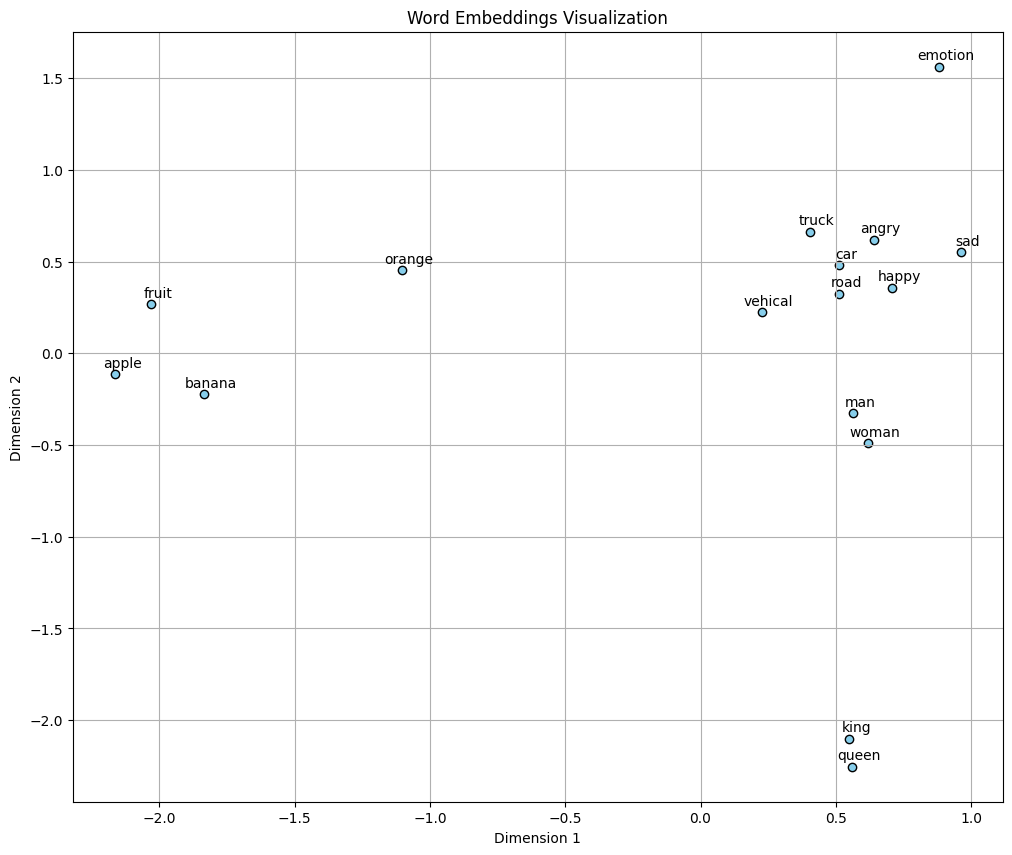

In [ ]:
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt
words_to_visualize = [
    'king','queen','man','woman',
    'apple','banana','orange','fruit',
    'car','truck','vehical','road',
    'happy','sad','angry','emotion'
]
filtered_word = [word for word in words_to_visualize if word in model.key_to_index]

vectors = [model[word] for word in filtered_word ]
pca = PCA(n_components=2)
vectors_2d = pca.fit_transform(vectors)

plt.figure(figsize=(12,10))
plt.scatter(vectors_2d[:,0], vectors_2d[:,1],edgecolors='k', c='skyblue')

for i, word in enumerate(filtered_word):
  plt.annotate(word, (vectors_2d[i, 0], vectors_2d[i, 1]),textcoords="offset points",xytext=(5, 5),ha='center')

plt.title("Word Embeddings Visualization")
plt.xlabel("Dimension 1")
plt.ylabel("Dimension 2")
plt.grid(True)
plt.show()
